Chapter 32
# 支持向量机，高斯核
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

##高斯核

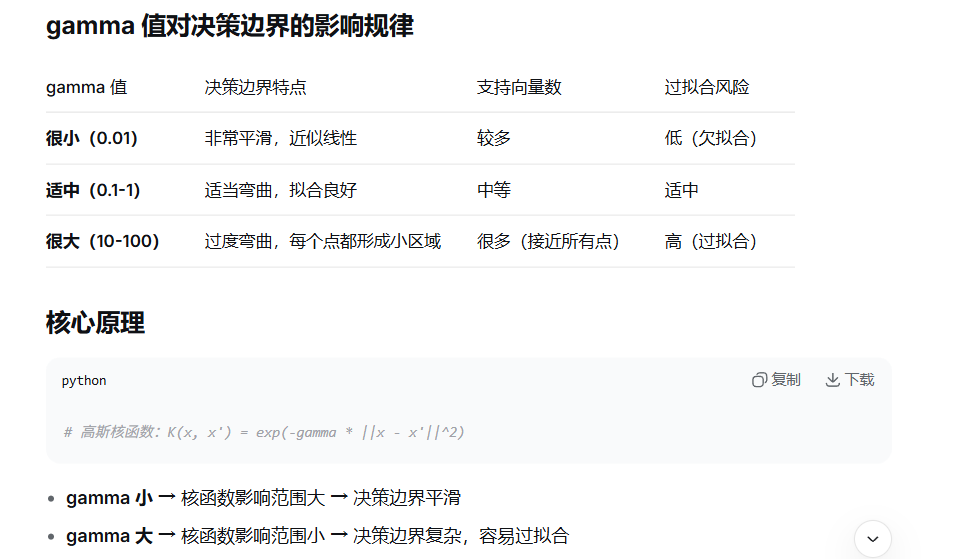

## **2维升3维；还是一个平面；只是三维空间的一个平面**

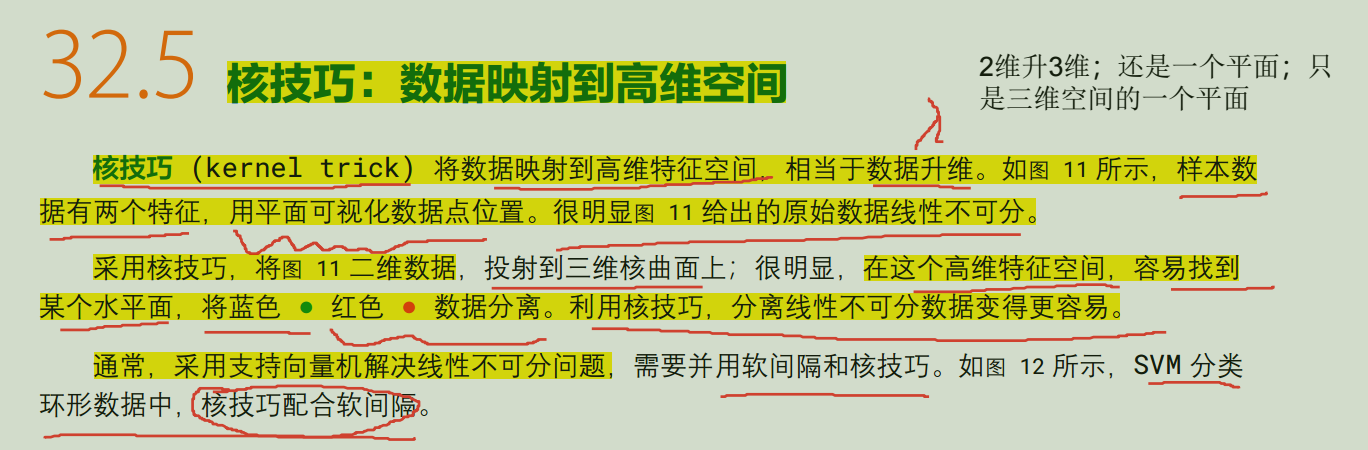

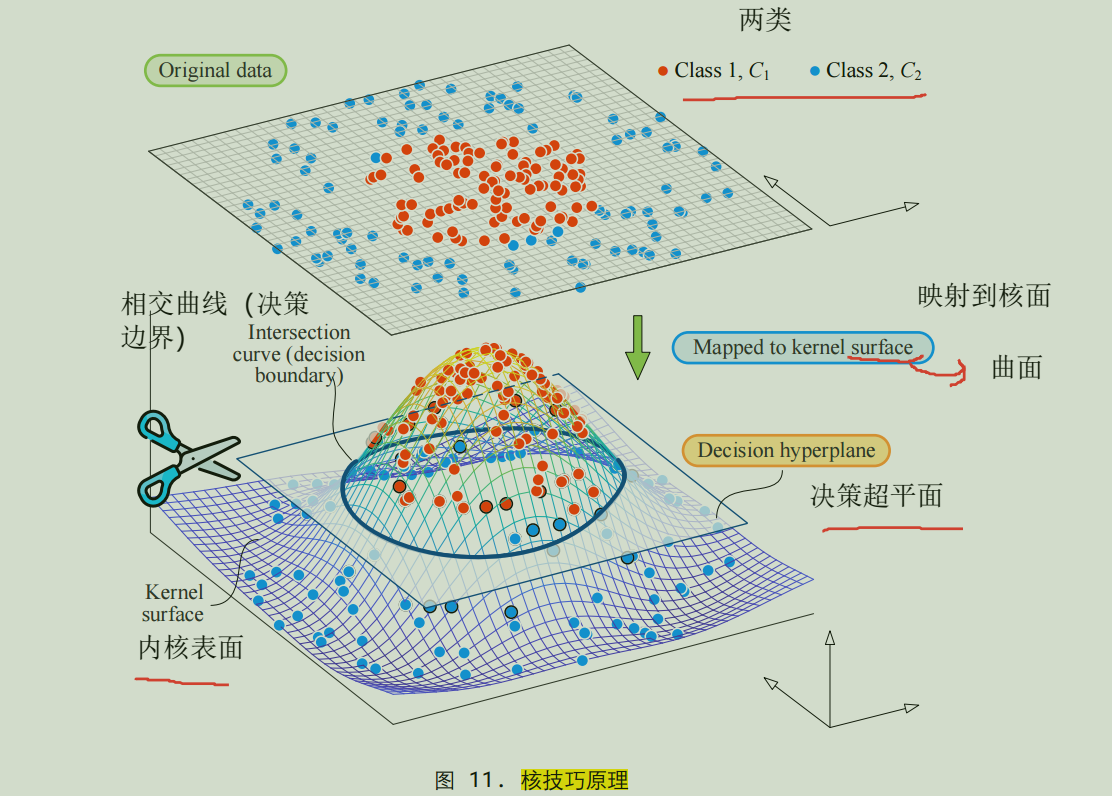

##将图像立起来就能找到一个超平面来分割数据

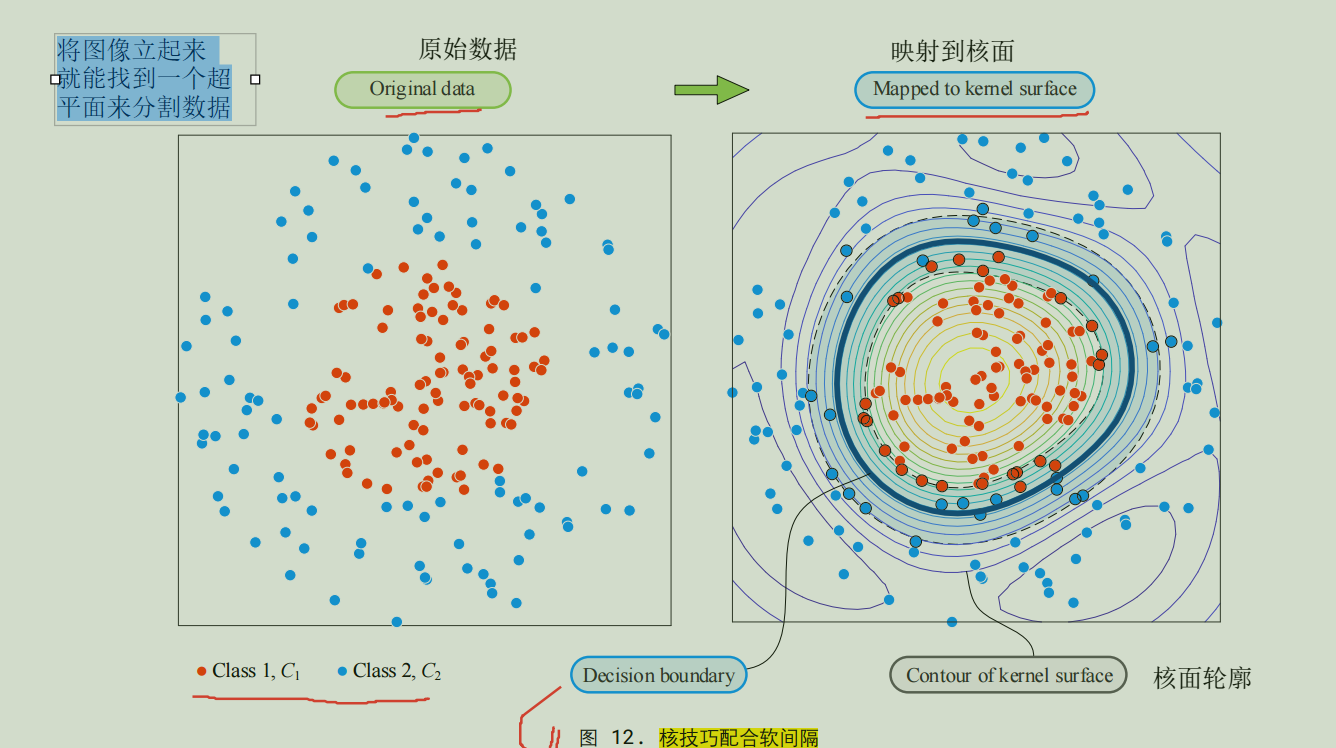

**决策边界：在机器学习和统计分类中，决策边界是一个超平面，用于区分不同类别的数据点。**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap # 颜色映射
from sklearn import neighbors, datasets

# # 导入并整理数据

In [2]:
# 导入并整理数据
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

### 生成网格化数据

In [3]:
# 生成网格化数据
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1, xx2 = np.meshgrid(x1_array,x2_array)

## 创建色谱

In [8]:
# 创建色谱
rgb = [[255, 238, 255],
       [219, 238, 244],
       [228, 228, 228]]
rgb = np.array(rgb)/255. # 归一化

# 预测区域的颜色
cmap_light = ListedColormap(rgb)
cmap_bold = [[255, 51, 0],
             [0, 153, 255],
             [138,138,138]]
# 数据点的颜色
cmap_bold = np.array(cmap_bold)/255.

#高斯核，也称为径向基核 (Radial Basis Function Kernel)，是 SVM 中常用的非线性核函
数。它能够将数据映射到无穷维的特征空间，从而在低维空间中不可分的数据变得线性可分。


**它能够将数据映射到无穷维的特征空间，从而在低维空间中不可分的数据变得线性可分。**

In [9]:
q = np.c_[xx1.ravel(), xx2.ravel()]
from sklearn import svm
# 创建支持向量机 (高斯核) 分类器对象
SVM = svm.SVC(kernel='rbf', gamma= 'auto') #rbf：高斯核
# 用训练数据训练kNN
SVM.fit(X, y) # 训练数据：原始数据与标签
# 用支持向量机 (高斯核) 分类器对一系列查询点进行预测
y_predict = SVM.predict(q)  # 预测数据
y_predict = y_predict.reshape(xx1.shape)

In [10]:
y_predict

array([[1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2]])

# 可视化

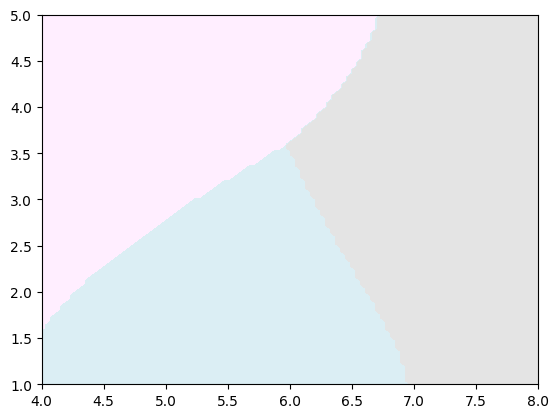

In [11]:
# 可视化
fig, ax = plt.subplots()
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)

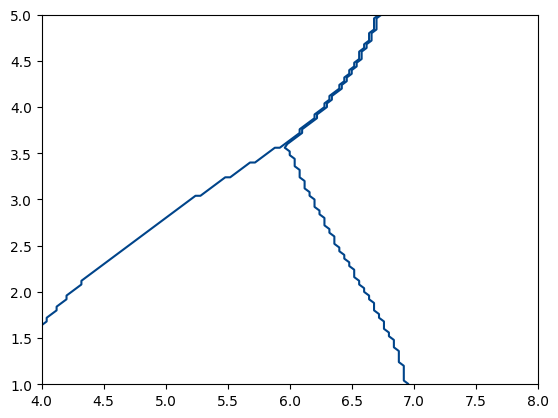

In [12]:
# 可视化
fig, ax = plt.subplots()
#plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

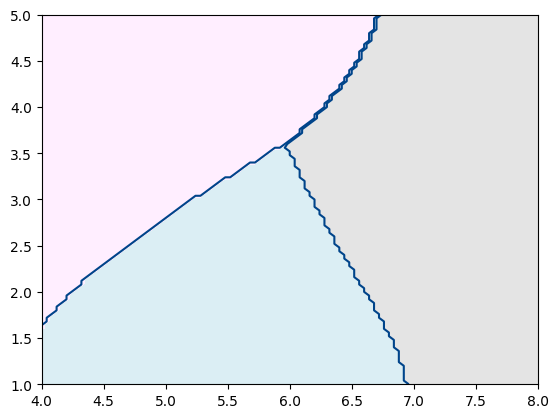

In [13]:
# 可视化
fig, ax = plt.subplots()
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

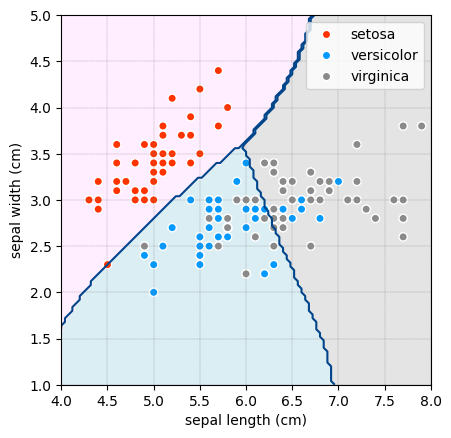

In [14]:
# 可视化
fig, ax = plt.subplots()

# 绘制等高线
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

# 绘制散点图
sns.scatterplot(x=X[:, 0], y=X[:, 1],
                hue=iris.target_names[y], #按照 'species' 列的值对数据点进行颜色分类
                ax = ax, # 轴对象
                palette=dict(setosa=cmap_bold[0,:], #设置颜色配色方案
                versicolor=cmap_bold[1,:],
                virginica=cmap_bold[2,:]),
                alpha=1.0,
                linewidth = 1, edgecolor=[1,1,1])  # 边缘为白色
plt.xlim(4, 8); plt.ylim(1, 5) # 范围
plt.xlabel(iris.feature_names[0])  # 标签
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  # 网格格式
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')  #x,y轴比例一致

# 观测gamma值的影响

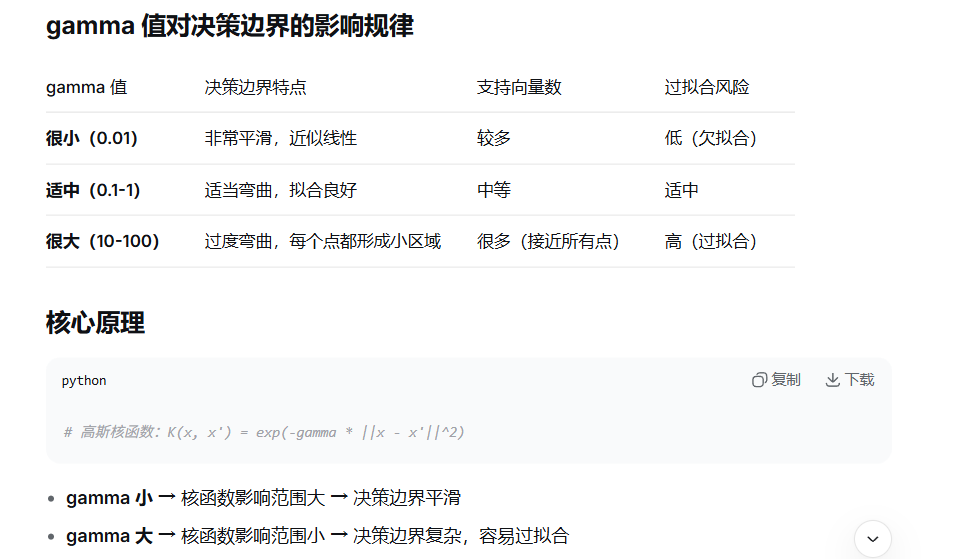

In [17]:
def picture(gamma, ax):
    # 创建支持向量机 (高斯核) 分类器对象
    SVM = svm.SVC(kernel='rbf', gamma= gamma)

    SVM.fit(X, y)  # 用训练数据训练kNN
    q = np.c_[xx1.ravel(), xx2.ravel()]
    # 用kNN对一系列查询点进行预测
    y_predict = SVM.predict(q)
    y_predict = y_predict.reshape(xx1.shape)

    # 可视化 - 所有 plt.xxx 改为 ax.xxx
    ax.contourf(xx1, xx2, y_predict, cmap=cmap_light)  # plt.contourf → ax.contourf
    ax.contour(xx1, xx2, y_predict, levels=[0,1,2],
               colors=np.array([0, 68, 138])/255.)  # plt.contour → ax.contour

    sns.scatterplot(x=X[:, 0], y=X[:, 1],
                    hue=iris.target_names[y],
                    ax=ax,  # 这个保持不变，已经传入了 ax
                    palette=dict(setosa=cmap_bold[0,:],
                                 versicolor=cmap_bold[1,:],
                                 virginica=cmap_bold[2,:]),
                    alpha=1.0,
                    linewidth=1, edgecolor=[1,1,1])

    # plt.xlim → ax.set_xlim, plt.ylim → ax.set_ylim
    ax.set_xlim(4, 8)
    ax.set_ylim(1, 5)
    ax.set_xlabel(iris.feature_names[0])  # plt.xlabel → ax.set_xlabel
    ax.set_ylabel(iris.feature_names[1])  # plt.ylabel → ax.set_ylabel
    ax.grid(linestyle='--', linewidth=0.25, color=[0.5,0.5,0.5])
    ax.set_aspect('equal', adjustable='box')

In [28]:
# 简单示例
a = [1, 2, 3]
b = ['a', 'b', 'c']
result = zip(a, b)
# 结果是：[(1, 'a'), (2, 'b'), (3, 'c')]
print(result)

0.1 Axes(0.125,0.53;0.227941x0.35)
0.5 Axes(0.398529,0.53;0.227941x0.35)
1 Axes(0.672059,0.53;0.227941x0.35)
2 Axes(0.125,0.11;0.227941x0.35)
5 Axes(0.398529,0.11;0.227941x0.35)
10 Axes(0.672059,0.11;0.227941x0.35)


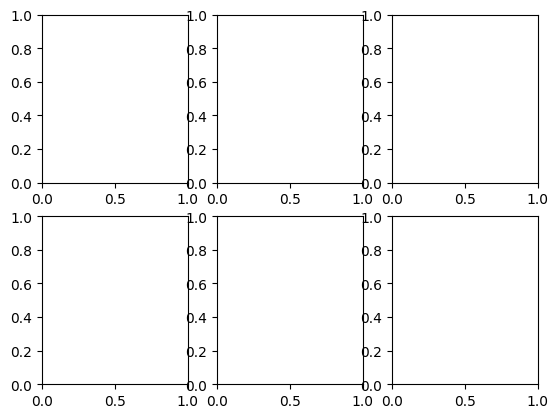

In [24]:
# 将 figsize 调大，例如 (18, 12) 或 (20, 15)
# 定义要测试的 gamma 值
gamma_values = [0.1, 0.5, 1, 2, 5, 10]  # 从小到大

fig, ax = plt.subplots(2, 3)  # 宽18英寸，高12英寸
for gamma,subplot in zip(gamma_values, ax.flat):
   print(gamma, subplot)


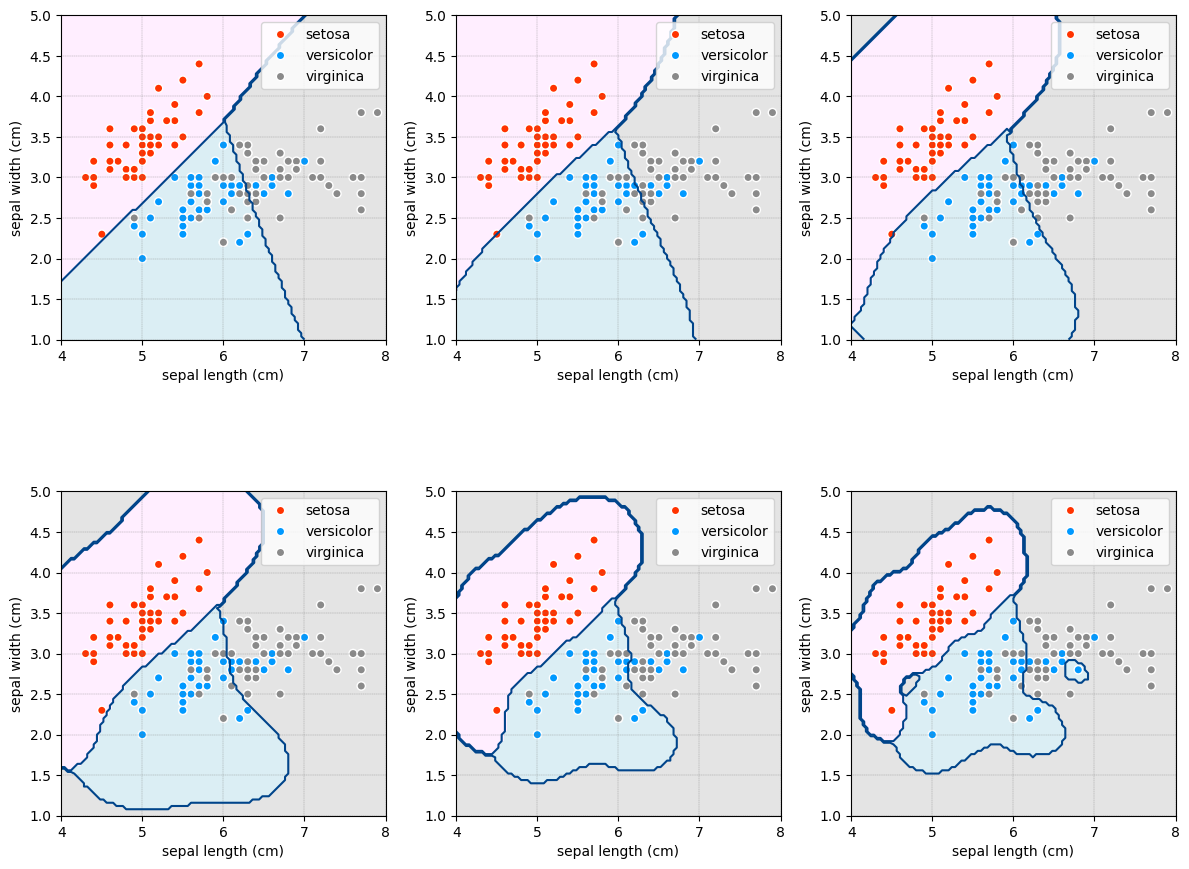

In [18]:
# 将 figsize 调大，例如 (18, 12) 或 (20, 15)
# 定义要测试的 gamma 值
gamma_values = [0.1, 0.5, 1, 2, 5, 10]  # 从小到大

fig, ax = plt.subplots(2, 3, figsize=(12, 10))  # 宽18英寸，高12英寸

for gamma,subplot in zip(gamma_values, ax.flat):
    picture(gamma, subplot)
plt.tight_layout()  # 自动调整间距
plt.show()

#方案1：在 2×3 子图中显示不同 gamma 值

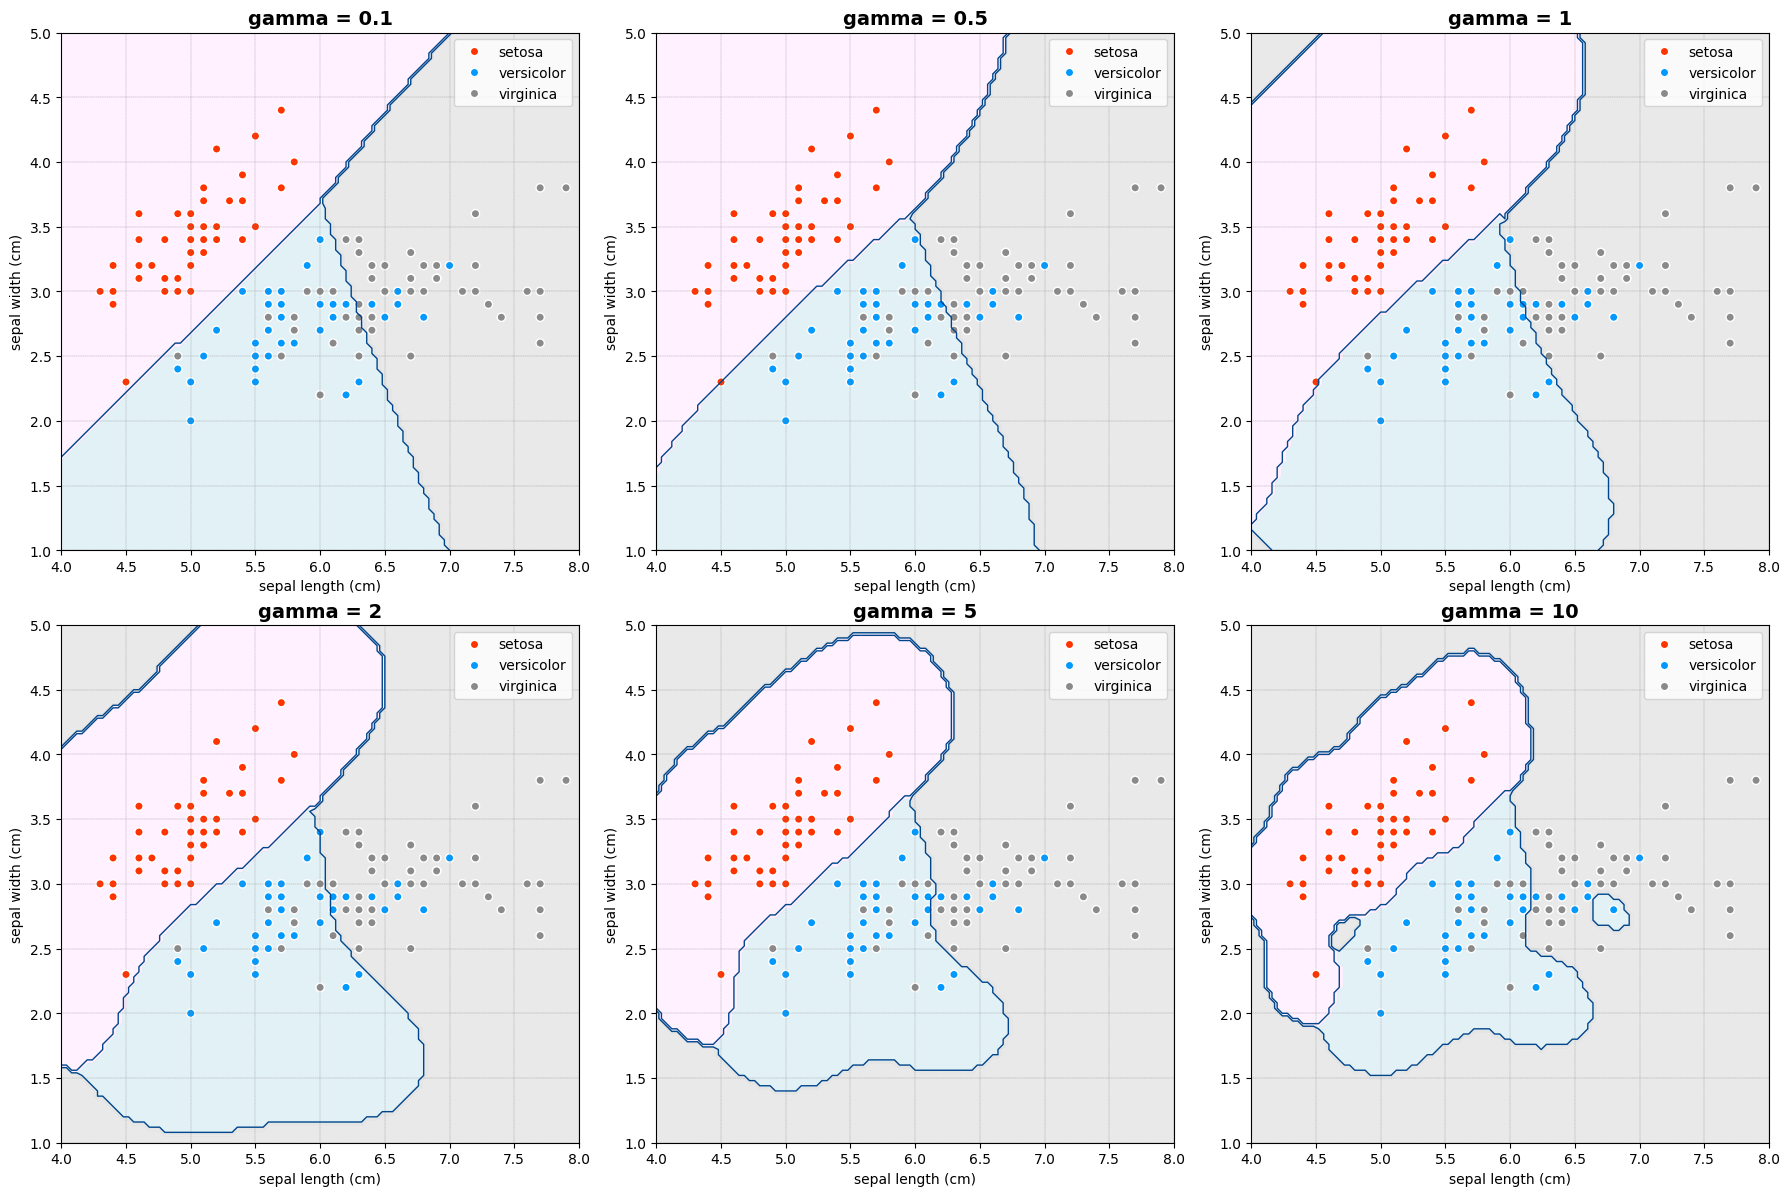

In [25]:
# from sklearn import svm
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from matplotlib.colors import ListedColormap

# 定义要测试的 gamma 值
gamma_values = [0.1, 0.5, 1, 2, 5, 10]  # 从小到大

# 创建 2×3 子图
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (gamma_val, ax) in enumerate(zip(gamma_values, axes.flat)):
    # 创建 SVM 分类器
    SVM = svm.SVC(kernel='rbf', gamma=gamma_val)
    SVM.fit(X, y)

    # 预测
    q = np.c_[xx1.ravel(), xx2.ravel()]
    y_predict = SVM.predict(q)
    y_predict = y_predict.reshape(xx1.shape)

    # 绘制决策边界
    ax.contourf(xx1, xx2, y_predict, cmap=cmap_light, alpha=0.8)
    ax.contour(xx1, xx2, y_predict, levels=[0, 1, 2],
               colors=np.array([0, 68, 138])/255., linewidths=1)

    # 绘制数据点
    sns.scatterplot(x=X[:, 0], y=X[:, 1],
                    hue=iris.target_names[y],
                    ax=ax,
                    palette=dict(setosa=cmap_bold[0,:],
                                 versicolor=cmap_bold[1,:],
                                 virginica=cmap_bold[2,:]),
                    alpha=1.0,
                    linewidth=1, edgecolor=[1,1,1])

    # 设置标题显示 gamma 值
    ax.set_title(f'gamma = {gamma_val}', fontsize=14, fontweight='bold')
    ax.set_xlim(4, 8)
    ax.set_ylim(1, 5)
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])
    ax.grid(linestyle='--', linewidth=0.25, color=[0.5,0.5,0.5])
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

#方案2：更精细的 gamma 值范围

/tmp/ipykernel_1407/901370324.py:48: UserWarning: Glyph 25903 (\N{CJK UNIFIED IDEOGRAPH-652F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1407/901370324.py:48: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1407/901370324.py:48: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1407/901370324.py:48: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1407/901370324.py:48: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25903 (\N{CJK UNIFIED IDEOGRAPH-652F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPyt

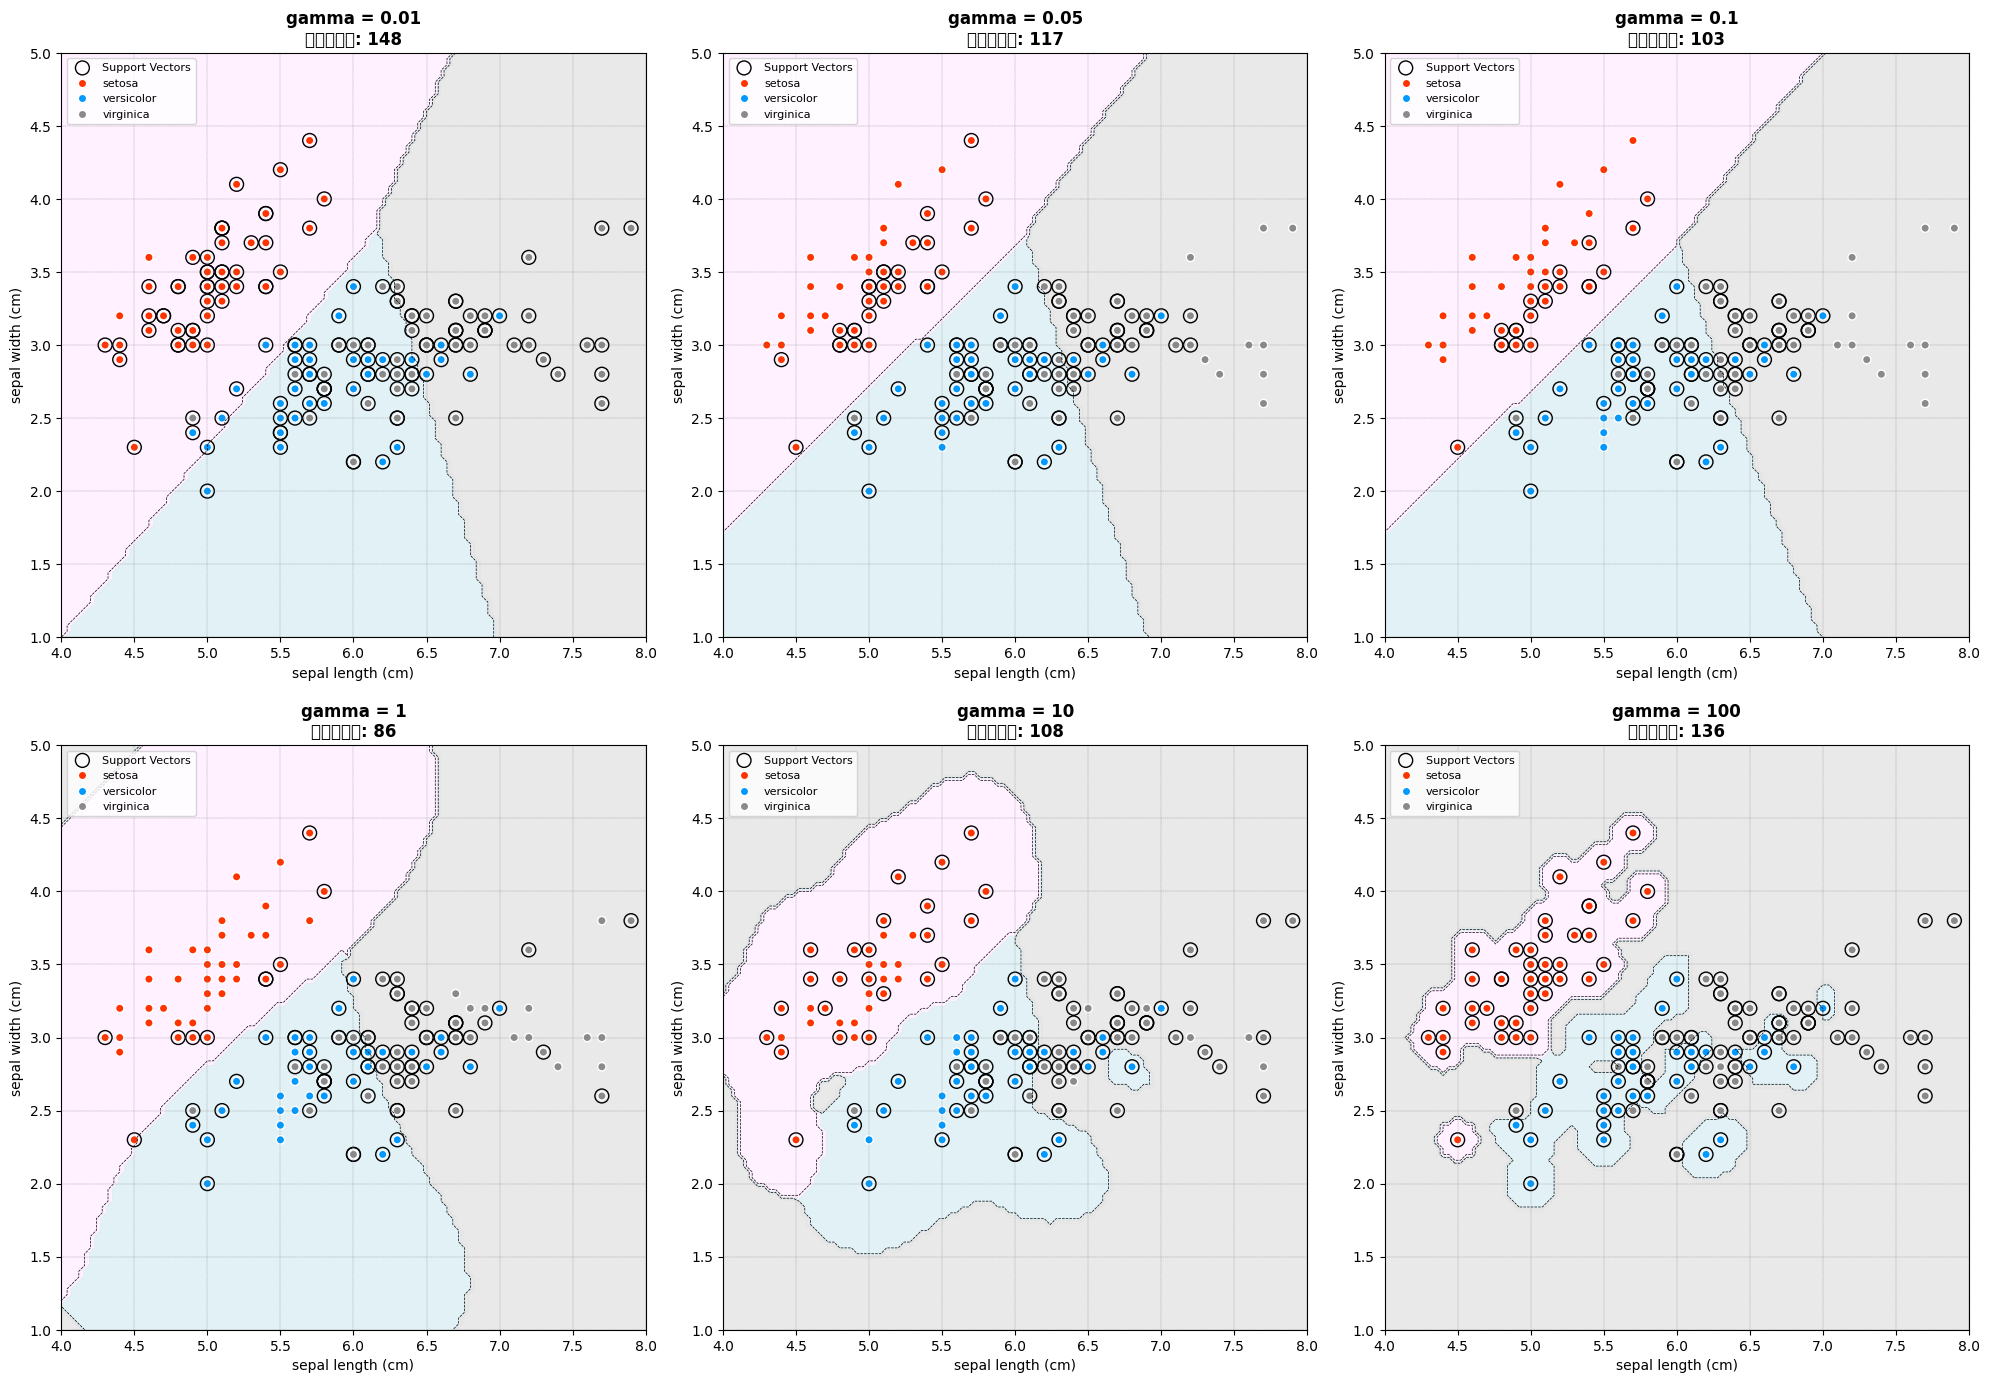

In [26]:
# 使用对数尺度选择 gamma 值，更好地展示变化
gamma_values = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 100]

# 选择其中6个有代表性的值
selected_gammas = [0.01, 0.05, 0.1, 1, 10, 100]

fig, axes = plt.subplots(2, 3, figsize=(20, 14))

for idx, (gamma_val, ax) in enumerate(zip(selected_gammas, axes.flat)):
    SVM = svm.SVC(kernel='rbf', gamma=gamma_val)
    SVM.fit(X, y)

    q = np.c_[xx1.ravel(), xx2.ravel()]
    y_predict = SVM.predict(q)
    y_predict = y_predict.reshape(xx1.shape)

    # 绘制决策边界
    ax.contourf(xx1, xx2, y_predict, cmap=cmap_light, alpha=0.8)
    ax.contour(xx1, xx2, y_predict, levels=[0, 1, 2],
               colors='black', linewidths=0.5, linestyles='--')

    # 绘制支持向量（可选）
    ax.scatter(SVM.support_vectors_[:, 0], SVM.support_vectors_[:, 1],
               s=100, facecolors='none', edgecolors='black',
               label='Support Vectors')

    sns.scatterplot(x=X[:, 0], y=X[:, 1],
                    hue=iris.target_names[y],
                    ax=ax,
                    palette=dict(setosa=cmap_bold[0,:],
                                 versicolor=cmap_bold[1,:],
                                 virginica=cmap_bold[2,:]),
                    alpha=1.0,
                    linewidth=1, edgecolor=[1,1,1])

    # 显示支持向量数量
    n_support = len(SVM.support_)
    ax.set_title(f'gamma = {gamma_val}\n支持向量数: {n_support}',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(4, 8)
    ax.set_ylim(1, 5)
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])
    ax.grid(linestyle='--', linewidth=0.25, color=[0.5,0.5,0.5])
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()